Описание/Пошаговая инструкция выполнения домашнего задания:
Цель задания — выявить группы потребителей с похожими паттернами (шаблонами поведенческой активности) покупок на основе временных рядов их транзакций.

Ссылка на набор данных:
https://archive.ics.uci.edu/dataset/352/online+retail

Типовые выполнения задания:

- Для начала проведите исследовательский анализ данных, Откорректируйте верно формат даты и времени, обработайте пропуски и выбросы, если они имеются.
  - ВНИМАНИЕ! Дополнительно можно выполнить извлечение признаков из табличных данных. Извлеките признаки из временных рядов, такие как:
    - Общее количество покупок за период
    - Средняя сумма покупки
    - Частота покупок (количество транзакций в неделю/месяц)
    - Сезонные паттерны (например, увеличение покупок в праздничные дни)
    - Временные интервалы между покупками и др.
- Преобразуйте данные в формат временных рядов, агрегируя транзакции по дням/неделям/месяцам обобщая количество или стоимость покупок.
- Нормализуйте данные, чтобы устранить влияние масштабов различных клиентов.
- Выполните кластеризацию временных рядов. Примените алгоритмы кластеризации, такие как K-средних (с различными метриками, в том числе DTW), DBSCAN или иерархическая кластеризация, к временным рядам. Для алгоритма K-средних определите оптимальное количество кластеров с помощью методов, таких как метод локтя или анализ силуэта.
- Анализ результатов: проанализируйте полученные кластеры, чтобы понять, какие группы потребителей были выделены. Определите характеристики каждой группы (например, "частые покупатели", "покупатели со средним чеком", "покупатели с сезонными паттернами").
- Визуализируйте результаты кластеризации с помощью соответствующих графиков и диаграмм, чтобы продемонстрировать различия между кластерами.

In [4]:
import pandas as pd
import numpy as np


# Подготовка

In [5]:
df = pd.read_excel('Online Retail.xlsx')

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
# удаляем записи, где нет данных о покупателе
df = df.dropna(subset='CustomerID')

In [9]:
# выделяем дату
df['Date'] = pd.to_datetime(df['InvoiceDate'].dt.date)

In [10]:
# убираем возвраты. "Если этот код начинается с буквы «c», это означает отмену"
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [11]:
# убираем явно некорректные значения количества и цены
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [12]:
# cчитаем выручку
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[us]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  str           
 8   Date         397884 non-null  datetime64[s] 
 9   Revenue      397884 non-null  float64       
dtypes: datetime64[s](1), datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 33.4+ MB


In [14]:
# Определение диапазона   дат
min_date = df["Date"].min()
max_date = df["Date"].max()
max_date - min_date

Timedelta('373 days 00:00:00')

Датафрейм получается большой, но попробуем сначала с ним

In [15]:
daily = df.groupby(['CustomerID', 'Date'])['Revenue'].sum().reset_index()
daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 16763 entries, 0 to 16762
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   CustomerID  16763 non-null  float64      
 1   Date        16763 non-null  datetime64[s]
 2   Revenue     16763 non-null  float64      
dtypes: datetime64[s](1), float64(2)
memory usage: 393.0 KB


In [16]:
all_dates = pd.date_range(min_date, max_date, freq="D")
daily_pivot = (
    daily
    .pivot(index="CustomerID", columns="Date", values="Revenue")
    .reindex(columns=all_dates)       # добавляем все дни во всём диапазоне
    .fillna(0.0)                      # отсутствие покупок = 0 выручки
)
daily_pivot

,2010-12-01,2010-12-02,2010-12-03,2010-12-04,2010-12-05,2010-12-06,2010-12-07,2010-12-08,2010-12-09,2010-12-10,...,2011-11-30,2011-12-01,2011-12-02,2011-12-03,2011-12-04,2011-12-05,2011-12-06,2011-12-07,2011-12-08,2011-12-09
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0
12347.0,0.0,0.0,0.0,0.0,0.0,0.0,711.79,0.0,0.0,0.0,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,224.82,0.0,0.0
12348.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0
12349.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0
12350.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0
18281.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0
18282.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.00,0.0,77.84,0.0,0.0,0.0,0.0,0.00,0.0,0.0


<Axes: xlabel='counts'>

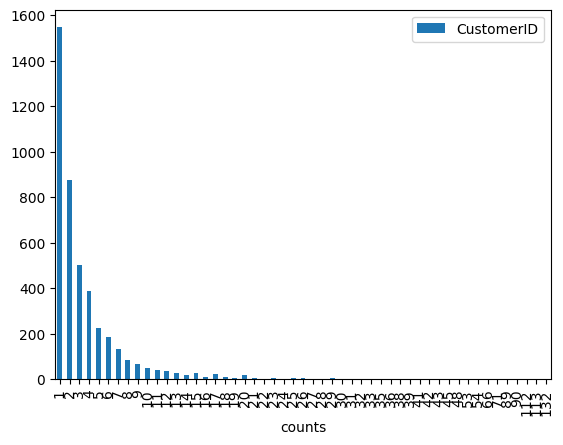

In [17]:
(daily_pivot>0).sum(axis=1).rename('counts').reset_index().groupby('counts').count().plot(kind='bar')

In [18]:
# Фильтрация клиентов по минимальному числу активных дней
min_active_days = 5  # можно изменить порог
active_days = (daily_pivot > 0).sum(axis=1)
mask = active_days >= min_active_days
daily_pivot_filtered = daily_pivot[mask]

In [19]:
# нормализация
def z_norm(row):
    mu = row.mean()
    sigma = row.std()
    if sigma == 0:
        return np.zeros_like(row)  # если ряд константный
    return (row - mu) / sigma

daily_pivot_norm = daily_pivot_filtered.apply(z_norm, axis=1)
daily_pivot_norm

,2010-12-01,2010-12-02,2010-12-03,2010-12-04,2010-12-05,2010-12-06,2010-12-07,2010-12-08,2010-12-09,2010-12-10,...,2011-11-30,2011-12-01,2011-12-02,2011-12-03,2011-12-04,2011-12-05,2011-12-06,2011-12-07,2011-12-08,2011-12-09
CustomerID,,,,,,,,,,,,,,,,,,,,,
12347.0,-0.122481,-0.122481,-0.122481,-0.122481,-0.122481,-0.122481,7.442632,-0.122481,-0.122481,-0.122481,...,-0.122481,-0.122481,-0.122481,-0.122481,-0.122481,-0.122481,-0.122481,2.266972,-0.122481,-0.122481
12352.0,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,...,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041,-0.110041
12362.0,-0.158303,-0.158303,-0.158303,-0.158303,-0.158303,-0.158303,-0.158303,-0.158303,-0.158303,-0.158303,...,-0.158303,-0.158303,-0.158303,-0.158303,-0.158303,-0.158303,5.834912,-0.158303,-0.158303,-0.158303
12381.0,-0.071068,-0.071068,-0.071068,-0.071068,-0.071068,-0.071068,-0.071068,-0.071068,-0.071068,-0.071068,...,-0.071068,-0.071068,-0.071068,-0.071068,-0.071068,2.046423,-0.071068,-0.071068,-0.071068,-0.071068
12383.0,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,...,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917,-0.098917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18245.0,-0.108438,-0.108438,-0.108438,-0.108438,-0.108438,-0.108438,-0.108438,-0.108438,-0.108438,-0.108438,...,-0.108438,-0.108438,14.019445,-0.108438,-0.108438,-0.108438,-0.108438,-0.108438,-0.108438,-0.108438
18257.0,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,...,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483,-0.120483
18260.0,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,...,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803,-0.123803


# Обогощаем данные

In [20]:
# агрегируем по чеку внутри клиента
invoice_agg = (
    df.groupby(["CustomerID", "InvoiceNo"], as_index=False)
      .agg(
          invoice_revenue=("Revenue", "sum"),   # сумма по чеку
          invoice_qty=("Quantity", "sum"),      # суммарное количество товаров
          n_lines=("StockCode", "count")        # число строк в чеке
      )
)
invoice_agg.head()

,CustomerID,InvoiceNo,invoice_revenue,invoice_qty,n_lines
0,12346.0,541431,77183.60,74215,1
1,12347.0,537626,711.79,319,31
2,12347.0,542237,475.39,315,29
3,12347.0,549222,636.25,483,24
4,12347.0,556201,382.52,196,18


In [21]:
#  Базовые RFM-фичи и производные 

# Monetary и общее количество товаров, уникальные товары, число активных дней
customer_basic = (
    df.groupby("CustomerID")
      .agg(
          total_quantity=("Quantity", "sum"),           # общее число товаров
          unique_products=("StockCode", "nunique"),     # уникальные товары
          monetary=("Revenue", "sum"),                  # сумма покупок
          n_active_days=("Date", "nunique"),            # число активных дней
          first_purchase_date=("Date", "min"),
          last_purchase_date=("Date", "max")
      )
)
customer_basic.head()

,total_quantity,unique_products,monetary,n_active_days,first_purchase_date,last_purchase_date
CustomerID,,,,,,
12346.0,74215,1,77183.60,1,2011-01-18,2011-01-18
12347.0,2458,103,4310.00,7,2010-12-07,2011-12-07
12348.0,2341,22,1797.24,4,2010-12-16,2011-09-25
12349.0,631,73,1757.55,1,2011-11-21,2011-11-21
12350.0,197,17,334.40,1,2011-02-02,2011-02-02


In [22]:
# число чеков
frequency = (
    invoice_agg.groupby("CustomerID")["InvoiceNo"]
               .nunique()
               .rename("frequency")
)

customer_basic = customer_basic.join(frequency)

In [23]:
# Средний чек и std чека
invoice_stats = (
    invoice_agg.groupby("CustomerID")
      .agg(
          mean_invoice_value=("invoice_revenue", "mean"),
          std_invoice_value=("invoice_revenue", "std"),
          mean_lines_per_invoice=("n_lines", "mean")
      )
)

customer_basic = customer_basic.join(invoice_stats)

In [24]:
# длительность "жизни" клиента в днях
customer_basic["customer_lifetime_days"] = (
    (customer_basic["last_purchase_date"] - customer_basic["first_purchase_date"])
    .dt.days
    .replace(0, 1)  # чтобы не делить на 0
)

In [25]:
# частота чеков в неделю
customer_basic["invoices_per_week"] = (
    customer_basic["frequency"] /
    (customer_basic["customer_lifetime_days"] / 7.0)
)

# частота чеков в месяц:
customer_basic["invoices_per_month"] = (
    customer_basic["frequency"] /
    (customer_basic["customer_lifetime_days"] / 30.0)
)

In [26]:
customer_features = customer_basic[
    [
        "total_quantity",           # общее количество товаров
        "unique_products",          # купленные уникальные товары
        "mean_invoice_value",       # средняя сумма покупки (чек)
        "invoices_per_week",        # частота покупок (в неделю)
        "invoices_per_month",       # частота покупок (в месяц)
        "frequency",                # число чеков
        "monetary",                 # общая выручка
        "std_invoice_value",        # std чека
        "n_active_days",            # число активных дней
        "mean_lines_per_invoice",   # среднее число строк в чеке
    ]
].copy()

In [27]:
customer_features

,total_quantity,unique_products,mean_invoice_value,invoices_per_week,invoices_per_month,frequency,monetary,std_invoice_value,n_active_days,mean_lines_per_invoice
CustomerID,,,,,,,,,,
12346.0,74215,1,77183.600000,7.000000,30.000000,1,77183.60,NaN,1,1.000000
12347.0,2458,103,615.714286,0.134247,0.575342,7,4310.00,341.070789,7,26.000000
12348.0,2341,22,449.310000,0.098940,0.424028,4,1797.24,301.159918,4,7.750000
12349.0,631,73,1757.550000,7.000000,30.000000,1,1757.55,NaN,1,73.000000
12350.0,197,17,334.400000,7.000000,30.000000,1,334.40,NaN,1,17.000000
...,...,...,...,...,...,...,...,...,...,...
18280.0,45,10,180.600000,7.000000,30.000000,1,180.60,NaN,1,10.000000
18281.0,54,7,80.820000,7.000000,30.000000,1,80.82,NaN,1,7.000000
18282.0,103,12,89.025000,0.117647,0.504202,2,178.05,15.817979,2,6.000000


# Кластеризация

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [37]:
def plot_scores(inertias= None, silhouettes=None):
    '''График для оценки качества кластеризации по метрикам инерции и силуэта'''
    fig, ax1 = plt.subplots(figsize=(10, 6))

    if inertias is not None:
        ax1.plot(range(1, len(inertias) + 1), inertias, marker='o', label='Inertia')
        ax1.set_xlabel('Number of Clusters (k)')
        ax1.set_ylabel('Inertia', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.legend(loc='upper left')

    if silhouettes is not None:
        ax2 = ax1.twinx()
        ax2.plot(range(2, len(silhouettes) + 2), silhouettes, marker='o', color='orange', label='Silhouette Score')
        ax2.set_ylabel('Silhouette Score', color='orange')
        ax2.tick_params(axis='y', labelcolor='orange')
        ax2.legend(loc='upper right')

    plt.title('KMeans Clustering Evaluation Metrics')
    plt.show()
    
def evaluate_kmeans(X, k_values=None):
    '''Оценка качества кластеризации KMeans для разных k'''
    inertias = []
    silhouettes = []
    
    if k_values is None:
        k_values = range(2, 11)  # по умолчанию от 2 до 10 кластеров
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        
        inertias.append(kmeans.inertia_)
        
        if k > 1:  # силуэт можно считать только при k > 1
            silhouette_avg = silhouette_score(X, labels)
            silhouettes.append(silhouette_avg)
        else:
            silhouettes.append(None)  # для k=1 силуэт не определён
    
    plot_scores(inertias=inertias, silhouettes=silhouettes)

## Kmeans и эвклид

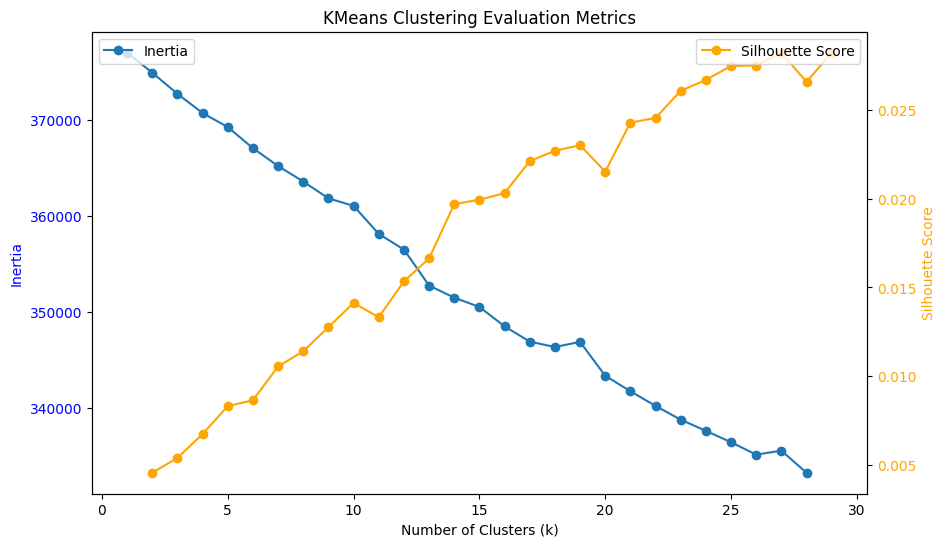

In [38]:
X = daily_pivot_norm.values
evaluate_kmeans(X, k_values=range(2, 30))

Весьма унылая картина, попробуем перейти к недельным данным

In [39]:
# убедимся, что столбцы — это DatetimeIndex
daily_pivot.columns = pd.to_datetime(daily_pivot.columns)

# ресемплируем по неделям: складываем выручку в пределах недели
# ось времени (столбцы) = недели
weekly_pivot = (
    daily_pivot_filtered
    .T                      # делаем даты строками
    .resample("W")          # недельная частота, по умолчанию по воскресеньям
    .sum()
    .T                      # обратно: строки = клиенты, столбцы = недели
)

# нормализуем по каждому клиенту (z-нормировка по строке)
def z_norm(row):
    mu = row.mean()
    sigma = row.std()
    if sigma == 0 or np.isnan(sigma):
        return np.zeros_like(row)
    return (row - mu) / sigma

weekly_pivot_norm = weekly_pivot.apply(z_norm, axis=1)

# матрица признаков для KMeans
X_weekly = weekly_pivot_norm.values

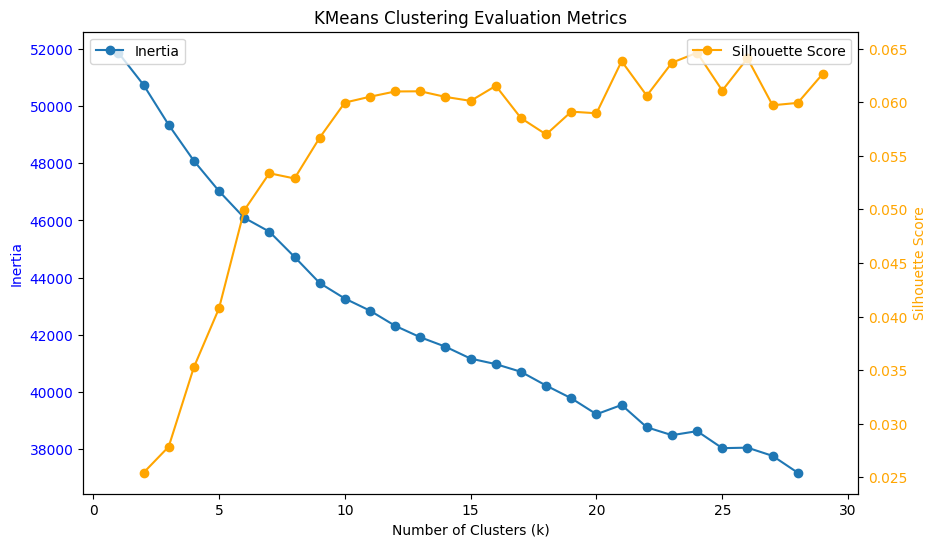

In [40]:
evaluate_kmeans(X_weekly, k_values=range(2, 30))

Недельный лучше, но все равно так себе

In [61]:
# Финальная модель
best_k = 12

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans_final.fit_predict(X_weekly)


# словарь CustomerID -> кластер
customer_cluster_euclid = pd.Series(
    cluster_labels,
    index=weekly_pivot_norm.index,
    name="cluster_kmeans_euclid"
)

In [60]:
customer_cluster_euclid

CustomerID
12347.0     2
12352.0     7
12362.0    10
12381.0     2
12383.0     9
           ..
18245.0     1
18257.0     8
18260.0     9
18272.0    10
18283.0     5
Name: cluster_kmeans_euclid, Length: 1026, dtype: int32

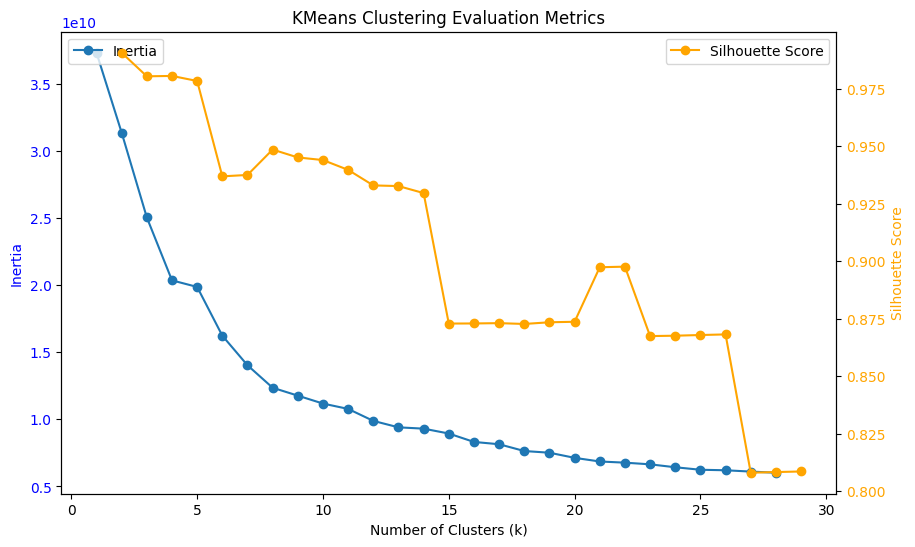

In [43]:
evaluate_kmeans(daily_pivot.values, k_values=range(2, 30))

In [62]:
# Финальная модель
best_k = 8

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans_final.fit_predict(X_weekly)


# словарь CustomerID -> кластер
customer_cluster_euclid_not_norm = pd.Series(
    cluster_labels,
    index=weekly_pivot_norm.index,
    name="cluster_kmeans_euclid_not_norm"
)

## K-Means + DTW

In [45]:
from tslearn.clustering import TimeSeriesKMeans


/Users/vadim/Code/OTUS/ML-Advanced/.venv/lib/python3.12/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [54]:
def evaluate_kmeans_dtw(X, k_values=None):
    '''Оценка качества кластеризации KMeans для разных k'''
    inertias = []
    silhouettes = []
    
    if k_values is None:
        k_values = range(2, 11)  # по умолчанию от 2 до 10 кластеров
    
    for k in k_values:
        kmeans = TimeSeriesKMeans(n_clusters=k, random_state=42, metric="dtw")
        labels = kmeans.fit_predict(X)
        
        inertias.append(kmeans.inertia_)
        
        if k > 1:  # силуэт можно считать только при k > 1
            silhouette_avg = silhouette_score(X, labels)
            silhouettes.append(silhouette_avg)
        else:
            silhouettes.append(None)  # для k=1 силуэт не определён
    
    plot_scores(inertias=inertias, silhouettes=silhouettes)

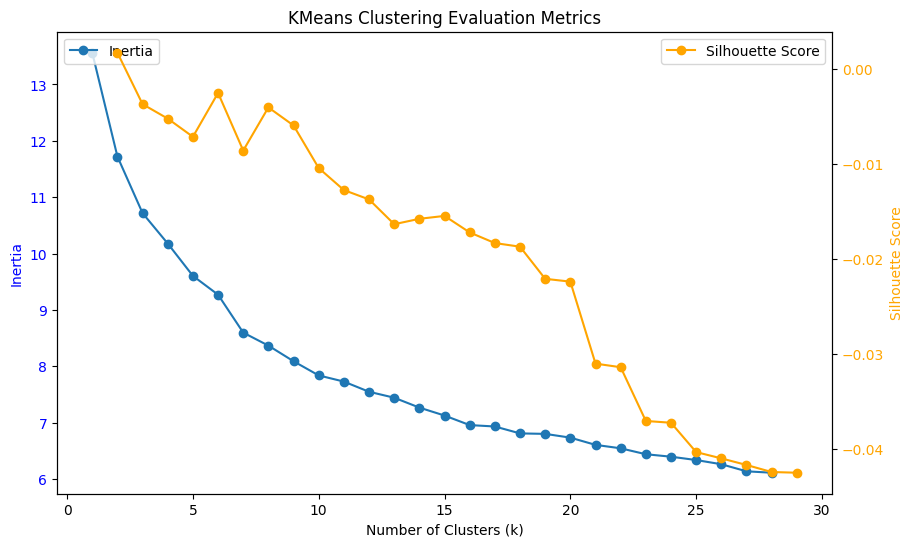

In [55]:
evaluate_kmeans_dtw(X_weekly, k_values=range(2, 30))

В целом похожие результаты. 

In [63]:
# Финальная модель
best_k = 7

kmeans_final = TimeSeriesKMeans(
    n_clusters=best_k,
    random_state=42,
    metric="dtw"

)
cluster_labels = kmeans_final.fit_predict(X_weekly)


# словарь CustomerID -> кластер
customer_cluster_dtw = pd.Series(
    cluster_labels,
    index=weekly_pivot_norm.index,
    name="cluster_kmeans_dtw"
)

## DBSCAN

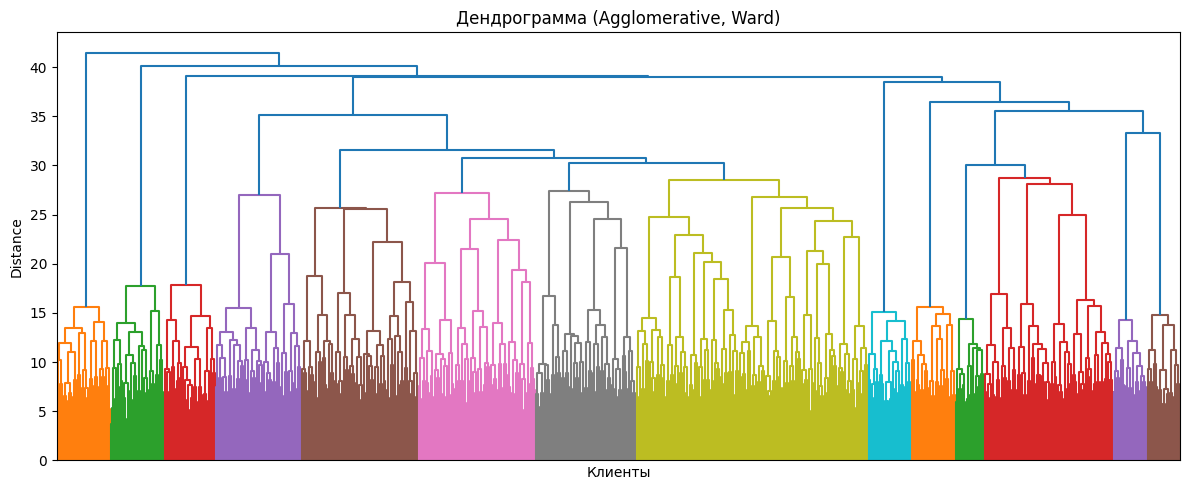

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_weekly, method="ward")  

plt.figure(figsize=(12, 5))
dendrogram(
    Z,
    no_labels=True,        
    color_threshold=None  
)
plt.title("Дендрограмма (Agglomerative, Ward)")
plt.xlabel("Клиенты")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [67]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 6

agg = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="ward"
)
labels_agg = agg.fit_predict(X_weekly)

customer_cluster_agg = pd.Series(
    labels_agg,
    index=weekly_pivot_norm.index,
    name="cluster_agg_ward"
)

## Cравнение

In [68]:
from sklearn.metrics import silhouette_score
import pandas as pd

X = weekly_pivot_norm.values

results = {}

labels_euclid = customer_cluster_euclid.values
results["kmeans_euclid"] = silhouette_score(X, labels_euclid, metric="euclidean")


labels_dtw = customer_cluster_dtw.values
results["kmeans_dtw"] = silhouette_score(X, labels_dtw, metric="euclidean")

labels_agg = customer_cluster_agg.values
results["agg_ward"] = silhouette_score(X, labels_agg, metric="euclidean")


print(pd.Series(results))

kmeans_euclid    0.062017
kmeans_dtw      -0.008621
agg_ward        -0.000529
dtype: float64


Получается, что лучшее это K-Means c эвклидом. 
Где я ошибся?

# Описание кластеров

In [69]:
weekly_with_cluster = weekly_pivot_norm.copy()
weekly_with_cluster["cluster"] = customer_cluster_euclid.values

In [70]:
weekly_with_cluster["cluster"].value_counts().sort_index()

cluster
0      83
1      65
2      78
3      85
4      65
5     100
6      68
7      66
8      91
9     170
10     85
11     70
Name: count, dtype: int64

In [71]:
weeks = weekly_pivot_norm.columns
clusters = weekly_with_cluster["cluster"]

centroids_weekly = (
    weekly_with_cluster
    .drop(columns="cluster")
    .groupby(clusters)
    .mean()
)

centroids_weekly

,2010-12-05 00:00:00,2010-12-12 00:00:00,2010-12-19 00:00:00,2010-12-26 00:00:00,2011-01-02 00:00:00,2011-01-09 00:00:00,2011-01-16 00:00:00,2011-01-23 00:00:00,2011-01-30 00:00:00,2011-02-06 00:00:00,...,2011-10-09 00:00:00,2011-10-16 00:00:00,2011-10-23 00:00:00,2011-10-30 00:00:00,2011-11-06 00:00:00,2011-11-13 00:00:00,2011-11-20 00:00:00,2011-11-27 00:00:00,2011-12-04 00:00:00,2011-12-11 00:00:00
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.112337,0.098376,-0.150840,-0.338853,-0.386531,-0.166780,-0.060988,-0.294393,-0.125591,-0.184101,...,-0.254275,0.092193,-0.123209,0.058171,-0.000733,0.181188,0.500099,0.473859,0.326344,0.187791
1,0.393158,0.059767,3.002696,-0.226743,-0.456794,0.127100,-0.066655,-0.070920,0.228836,-0.043573,...,-0.095983,0.097092,-0.385459,0.042876,-0.206392,-0.128972,0.130296,0.330308,0.579342,0.291779
2,0.058754,-0.042087,-0.035981,-0.355357,-0.404797,-0.056396,-0.009358,-0.146301,-0.083527,-0.170909,...,-0.089068,-0.244987,-0.109662,-0.317922,3.304414,-0.155506,0.079864,0.192934,0.391948,0.199544
3,-0.044579,3.172607,0.038484,-0.275502,-0.413902,0.035598,-0.277013,-0.065994,-0.003182,-0.163641,...,-0.119469,0.015240,-0.229510,-0.174680,0.173609,0.046281,0.211232,0.353167,0.478050,0.688259
4,-0.056204,-0.255435,-0.193230,-0.356787,-0.358170,-0.349895,-0.135381,-0.121689,-0.176862,-0.081658,...,-0.255402,3.290368,-0.266502,-0.049257,0.083272,0.249108,0.488287,0.576180,0.479693,0.295837
5,0.030053,0.034894,-0.052351,-0.311994,-0.457302,-0.124223,-0.225069,-0.181448,-0.112323,-0.094014,...,-0.118861,-0.238833,-0.171949,-0.120105,-0.236794,3.095656,-0.125585,0.397672,0.333339,0.309221
6,-0.156170,0.172891,-0.192655,-0.350998,-0.381836,-0.229958,-0.096268,-0.228873,-0.362992,0.072242,...,-0.049530,-0.166133,0.102864,0.313184,0.201778,0.103999,0.313106,0.194416,0.344476,0.242069
7,-0.030230,-0.170332,-0.188881,-0.300325,-0.376154,-0.179658,0.021068,-0.163813,-0.150588,-0.215801,...,-0.232523,-0.017129,-0.209902,-0.077552,0.141260,0.310049,0.322126,0.011440,0.073275,0.102278
8,-0.030870,-0.187269,-0.038694,-0.187284,-0.376910,-0.229785,-0.113195,-0.094866,0.025469,-0.137714,...,3.589632,-0.291091,-0.141142,-0.175322,0.007142,-0.057307,0.725483,0.270815,0.228652,0.057365


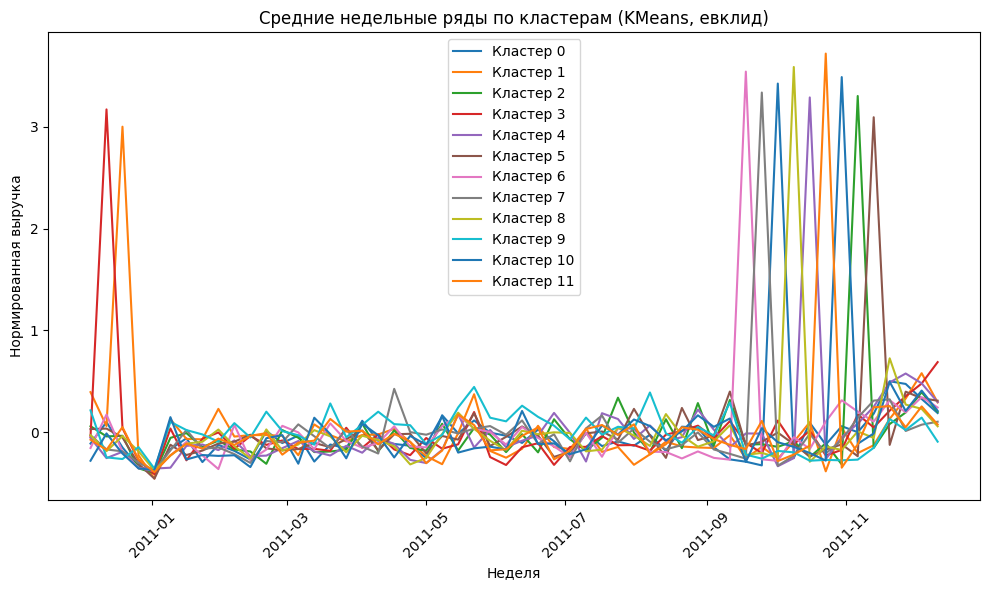

In [72]:
plt.figure(figsize=(10, 6))
for c in centroids_weekly.index:
    plt.plot(
        weeks,
        centroids_weekly.loc[c],
        label=f"Кластер {c}"
    )

plt.xticks(rotation=45)
plt.xlabel("Неделя")
plt.ylabel("Нормированная выручка")
plt.title("Средние недельные ряды по кластерам (KMeans, евклид)")
plt.legend()
plt.tight_layout()
plt.show()

- Большинство кластеров показывают одиночный сильный пик активности (1–2 недели с высокой нормированной выручкой) на фоне длительного «шума» вокруг нуля — клиенты редко покупают, но иногда делают одну крупную закупку.  
- Пики разных кластеров приходятся на разные периоды года (видно, что у одних всплеск в начале года, у других ближе к концу), поэтому алгоритм в основном делит клиентов по времени, когда у них случился главный заказ, а не по общей частоте или уровню.  
- В промежутках между этими пиками уровни примерно одинаковые и близки к среднему, поэтому кроме «позиции пика» сами формы рядов сильно не различаются; это соответствует небольшому значению силуэта у KMeans и слабой естественной кластерной структуре.  


In [73]:
features_with_cluster = customer_features.join(customer_cluster_euclid)
features_with_cluster.head()

,total_quantity,unique_products,mean_invoice_value,invoices_per_week,invoices_per_month,frequency,monetary,std_invoice_value,n_active_days,mean_lines_per_invoice,cluster_kmeans_euclid
CustomerID,,,,,,,,,,,
12346.0,74215,1,77183.600000,7.000000,30.000000,1,77183.60,NaN,1,1.00,NaN
12347.0,2458,103,615.714286,0.134247,0.575342,7,4310.00,341.070789,7,26.00,2.0
12348.0,2341,22,449.310000,0.098940,0.424028,4,1797.24,301.159918,4,7.75,NaN
12349.0,631,73,1757.550000,7.000000,30.000000,1,1757.55,NaN,1,73.00,NaN
12350.0,197,17,334.400000,7.000000,30.000000,1,334.40,NaN,1,17.00,NaN


In [74]:
cluster_summary = (
    features_with_cluster
    .groupby("cluster_kmeans_euclid")
    .agg(
        total_quantity_mean=("total_quantity", "mean"),
        unique_products_mean=("unique_products", "mean"),
        mean_invoice_value_mean=("mean_invoice_value", "mean"),
        invoices_per_week_mean=("invoices_per_week", "mean"),
        frequency_mean=("frequency", "mean"),
        monetary_mean=("monetary", "mean"),
        std_invoice_value_mean=("std_invoice_value", "mean"),
        n_active_days_mean=("n_active_days", "mean"),
        mean_lines_per_invoice_mean=("mean_lines_per_invoice", "mean")
    )
)

cluster_summary.round(2)

,total_quantity_mean,unique_products_mean,mean_invoice_value_mean,invoices_per_week_mean,frequency_mean,monetary_mean,std_invoice_value_mean,n_active_days_mean,mean_lines_per_invoice_mean
cluster_kmeans_euclid,,,,,,,,,
0.0,1949.01,131.66,328.86,0.29,11.47,3374.95,145.69,9.78,19.55
1.0,2978.45,156.51,369.45,0.32,14.38,5254.79,180.18,12.74,21.68
2.0,2733.18,119.74,389.91,0.27,10.87,4711.89,230.88,9.88,20.28
3.0,3450.47,138.74,446.69,0.24,12.04,5775.00,243.04,10.74,22.60
4.0,2497.02,127.71,501.95,0.30,9.35,5565.77,330.40,8.60,24.84
5.0,3481.33,154.61,386.20,0.34,14.27,5773.13,193.13,12.94,24.50
6.0,3308.16,133.99,469.39,0.27,10.57,7964.57,303.63,9.03,23.70
7.0,3720.08,118.08,462.50,0.27,10.89,7263.10,317.60,9.36,21.51
8.0,4001.40,128.16,492.83,0.28,10.51,6849.79,386.08,9.09,22.23


Объединим 12 кластеров в несколько более понятных сегментов.

#### Топ‑клиенты (очень высокий оборот)

- **Кластер 11**:
    - Самый высокий monetary (≈10.6k), очень много товара (≈7.3k единиц), широкий ассортимент (≈188 SKU), большие корзины (≈25 строк).
    - Достаточно частые покупки (frequency ≈13.8).
    - Сегмент: «топ‑клиенты с крупными и частыми заказами, высокой выручкой и широчайшим ассортиментом».


#### Крупные, но менее частые покупатели

- **Кластеры 6, 7, 8**:
    - Высокий monetary (≈6.8–8.0k) при средней частоте (frequency ≈10–11).
    - Высокий средний чек (≈460–490), крупные корзины и широкий ассортимент.
    - У 8 особенно большая вариативность чека (std очень высокое).
    - Сегмент: «редковатые, но дорогие и многопозиционные заказы, крупные B2B‑клиенты».


#### Частые средние/крупные покупатели

- **Кластеры 1, 3, 5, 10**:
    - Monetary на уровне ≈5–5.8k, частота выше средней (frequency ≈11–14).
    - Средний чек 370–450, корзины 22–25 строк, ассортимент широкий.
    - Сегмент: «регулярные активные клиенты со стабильной выручкой и широкими корзинами».


#### Редкие, но крупные заказы

- **Кластер 4**:
    - Frequency ≈9.3 ниже, monetary ≈5.6k, зато самый высокий средний чек (≈502) и крупные корзины.
    - Меньше активных дней, чем у «частых».
    - Сегмент: «редкие, но очень объёмные покупки».


#### Средние по объёму, «обычные» клиенты

- **Кластеры 0, 2, 9**:
    - Monetary ≈3.4–5.3k, frequency ≈10–11.
    - Ассортимент и корзины поменьше (особенно у 9, где меньше строк и SKU).
    - У 2 высокая вариативность чеков.
    - Сегмент: «средние клиенты, часть с узкой корзиной, часть с нестабильными чеками».

